# Objective 1 – Requirements Engineering using GR4ML

The requirements of the predictive maintenance system are developed using the GR4ML framework. The framework provides a structured approach for translating business objectives into analytics requirements, preparing data for machine learning, and identifying the quality requirements that guide the software architecture and implementation of the application.

The following diagram provides an overview of the GR4ML workflow used throughout Objective 1.

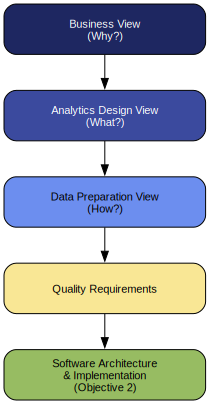

In [2]:
import graphviz

gr4ml = graphviz.Digraph("GR4ML_Workflow", format="png")

gr4ml.attr(
    rankdir="TB",
    bgcolor="white",
    fontname="Helvetica",
    labelloc="t"
)

gr4ml.attr(
    "node",
    shape="box",
    style="rounded,filled",
    fontname="Helvetica",
    fontsize="11",
    width="2.8",
    height="0.7"
)

# Nodes
gr4ml.node(
    "BV",
    "Business View\n(Why?)",
    fillcolor="#1E2761",
    fontcolor="white"
)

gr4ml.node(
    "AV",
    "Analytics Design View\n(What?)",
    fillcolor="#3B4A9E",
    fontcolor="white"
)

gr4ml.node(
    "DP",
    "Data Preparation View\n(How?)",
    fillcolor="#6C8EEF"
)

gr4ml.node(
    "QR",
    "Quality Requirements",
    fillcolor="#F9E795"
)

gr4ml.node(
    "SA",
    "Software Architecture\n& Implementation\n(Objective 2)",
    fillcolor="#97BC62"
)

# Flow
gr4ml.edge("BV", "AV")
gr4ml.edge("AV", "DP")
gr4ml.edge("DP", "QR")
gr4ml.edge("QR", "SA")

gr4ml

**Figure 3.1:** Overall GR4ML requirements engineering workflow adopted for the predictive maintenance system.

The GR4ML framework was used to capture the business requirements, translate them into analytics goals, prepare the required data for machine learning, and identify the quality requirements of the system. These requirements form the foundation for the software architecture and implementation discussed in Objective 2.

# 1. Business View (Why the system is needed)

The Business View establishes the core strategic framework by identifying the actors involved, their strategic motivations, the key technical decisions to be made, and the performance indicators used to measure business value.

Actors:

Fleet Maintenance Manager: Responsible for optimizing maintenance schedules, reducing budget overheads, and maximizing asset availability.

Field Service Technician: Needs actionable, localized repair guidance when an asset breaks down or flags a component anomaly.

OEM Reliability Engineer: Analyzes long-term structural and asset degradation trends across the machine fleet to improve engineering designs.

Strategic Goal: Minimize unplanned heavy machinery downtime and optimize field technician dispatch windows.

Decision Goals:

Batch-Level serving: Schedule condition-based maintenance for a specific asset component (cooler, valve, pump, accumulator) before catastrophic mechanical failure.

Real-Time serving: Immediately flag acute circuit instability to safe-guard operator safety.

Question Goals: "What is the specific degradation index for the primary components on Machine X?" and "Is the dynamic circuit path stable at this exact operating cycle?"

Insights: Cryptographically verified multi-task health condition scores (100/20/3 for cooler, etc.) along with real-time operational circuit stability binary flags.

Indicators: Mean-Time-Between-Failures (MTBF), Unplanned downtime hours per month, and total maintenance cost per machine per year.

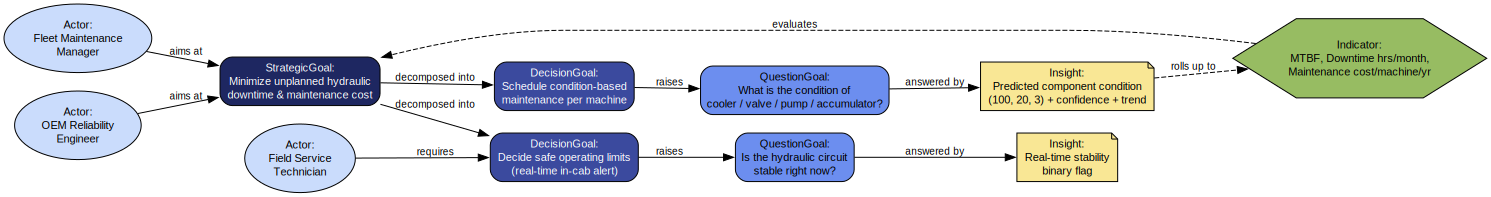

In [10]:
from graphviz import Source

dot_source = """
digraph BusinessView {
    rankdir=LR;
    bgcolor="white";
    fontname="Helvetica";
    node [fontname="Helvetica", fontsize="11"];
    edge [fontname="Helvetica", fontsize="10"];

    A1 [label="Actor:\\nFleet Maintenance\\nManager", shape=ellipse, style=filled, fillcolor="#CADCFC"];
    A2 [label="Actor:\\nField Service\\nTechnician", shape=ellipse, style=filled, fillcolor="#CADCFC"];
    A3 [label="Actor:\\nOEM Reliability\\nEngineer", shape=ellipse, style=filled, fillcolor="#CADCFC"];

    SG1 [label="StrategicGoal:\\nMinimize unplanned hydraulic\\ndowntime & maintenance cost", shape=box, style="rounded,filled", fillcolor="#1E2761", fontcolor="white"];

    DG1 [label="DecisionGoal:\\nSchedule condition-based\\nmaintenance per machine", shape=box, style="rounded,filled", fillcolor="#3B4A9E", fontcolor="white"];
    DG2 [label="DecisionGoal:\\nDecide safe operating limits\\n(real-time in-cab alert)", shape=box, style="rounded,filled", fillcolor="#3B4A9E", fontcolor="white"];

    QG1 [label="QuestionGoal:\\nWhat is the condition of\\ncooler / valve / pump / accumulator?", shape=box, style="rounded,filled", fillcolor="#6C8EEF", fontcolor="black"];
    QG2 [label="QuestionGoal:\\nIs the hydraulic circuit\\nstable right now?", shape=box, style="rounded,filled", fillcolor="#6C8EEF", fontcolor="black"];

    I1 [label="Insight:\\nPredicted component condition\\n(100, 20, 3) + confidence + trend", shape=note, style=filled, fillcolor="#F9E795"];
    I2 [label="Insight:\\nReal-time stability\\nbinary flag", shape=note, style=filled, fillcolor="#F9E795"];

    IND1 [label="Indicator:\\nMTBF, Downtime hrs/month,\\nMaintenance cost/machine/yr", shape=hexagon, style=filled, fillcolor="#97BC62"];

    A1 -> SG1 [label="aims at"];
    A2 -> DG2 [label="requires"];
    A3 -> SG1 [label="aims at"];

    SG1 -> DG1 [label="decomposed into"];
    SG1 -> DG2 [label="decomposed into"];

    DG1 -> QG1 [label="raises"];
    DG2 -> QG2 [label="raises"];

    QG1 -> I1 [label="answered by"];
    QG2 -> I2 [label="answered by"];

    I1 -> IND1 [label="rolls up to", style=dashed];
    IND1 -> SG1 [label="evaluates", style=dashed];
}
"""
Source(dot_source)


# 2. Analytics Design View (What the machine learning system solves)
The Analytics Design View maps the prediction challenges to concrete analytical approaches, outlining how different algorithms score against non-functional quality attributes (SoftGoals).
Prediction Goal 1 (Batch Condition Classification): A multi-output classification task to determine the categorical health condition indices (cooler_condition, valve_condition, pump_leakage, accumulator_pressure) simultaneously using historical work-cycle statistics.
Prediction Goal 2 (Real-Time Stability Classification): A high-speed binary classification task to determine whether the dynamic state of the machine cycle is operational or unstable (stability_flag).
Algorithms Considered: Multi-Output Random Forest, Gradient Boosted Decision Trees (GBDT), and Logistic Regression.
SoftGoals Enforced:
- Accuracy / F1-Score: High recall is necessary to capture true equipment degradation.
- Interpretability: Technicians must understand why a component was flagged to build system trust.
- Inference Latency: Critical for the in-cab real-time stability loop ($< 100\text{ ms}$).
- Robustness to Sensor Noise: Essential for handling sensor dropouts in harsh environments.
Trade-Off Rationale: While GBDTs show high accuracy (+), they introduce longer inference latency (-) and behave as black boxes (-). Random Forest architectures strongly support accuracy (+), possess built-in architectural robustness to data variance (+), allow clear explainability via feature importance (+), and meet our real-time serving latency thresholds (+).

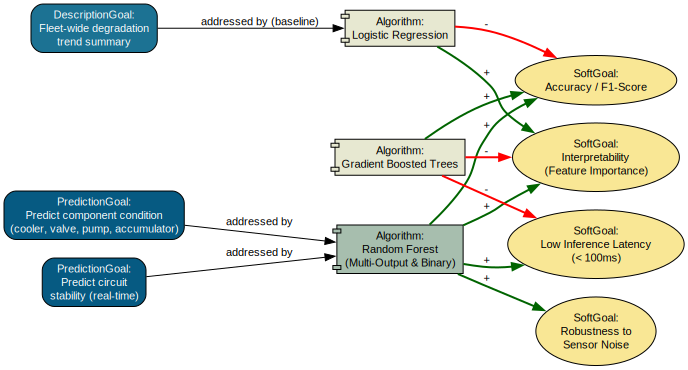

In [11]:
from graphviz import Source

dot_source = """
digraph AnalyticsDesignView {
    rankdir=LR;
    bgcolor="white";
    fontname="Helvetica";
    node [fontname="Helvetica", fontsize="11"];
    edge [fontname="Helvetica", fontsize="11"];

    // Prediction/Description Goals (Dark Teal)
    PG1 [label="PredictionGoal:\\nPredict component condition\\n(cooler, valve, pump, accumulator)", shape=box, style="rounded,filled", fillcolor="#065A82", fontcolor="white"];
    PG2 [label="PredictionGoal:\\nPredict circuit\\nstability (real-time)", shape=box, style="rounded,filled", fillcolor="#065A82", fontcolor="white"];
    DG1 [label="DescriptionGoal:\\nFleet-wide degradation\\ntrend summary", shape=box, style="rounded,filled", fillcolor="#1C7293", fontcolor="white"];

    // Algorithms (Component Shape)
    ALG1 [label="Algorithm:\\nLogistic Regression", shape=component, style=filled, fillcolor="#E7E8D1"];
    ALG2 [label="Algorithm:\\nRandom Forest\\n(Multi-Output & Binary)", shape=component, style=filled, fillcolor="#A7BEAE"];
    ALG3 [label="Algorithm:\\nGradient Boosted Trees", shape=component, style=filled, fillcolor="#E7E8D1"];

    // SoftGoals (Yellow Ellipses)
    SG1 [label="SoftGoal:\\nAccuracy / F1-Score", shape=ellipse, style=filled, fillcolor="#F9E795"];
    SG2 [label="SoftGoal:\\nInterpretability\\n(Feature Importance)", shape=ellipse, style=filled, fillcolor="#F9E795"];
    SG3 [label="SoftGoal:\\nLow Inference Latency\\n(< 100ms)", shape=ellipse, style=filled, fillcolor="#F9E795"];
    SG4 [label="SoftGoal:\\nRobustness to\\nSensor Noise", shape=ellipse, style=filled, fillcolor="#F9E795"];

    // Connections
    PG1 -> ALG2 [label="addressed by"];
    PG2 -> ALG2 [label="addressed by"];
    DG1 -> ALG1 [label="addressed by (baseline)"];

    // GBDT impacts
    ALG3 -> SG1 [label="+", color="darkgreen", penwidth=2];
    ALG3 -> SG2 [label="-", color="red", penwidth=2];
    ALG3 -> SG3 [label="-", color="red", penwidth=2];

    // Selected Random Forest impacts
    ALG2 -> SG1 [label="+", color="darkgreen", penwidth=2];
    ALG2 -> SG2 [label="+", color="darkgreen", penwidth=2];
    ALG2 -> SG3 [label="+", color="darkgreen", penwidth=2];
    ALG2 -> SG4 [label="+", color="darkgreen", penwidth=2];

    // Logistic Regression impacts
    ALG1 -> SG2 [label="+", color="darkgreen", penwidth=2];
    ALG1 -> SG1 [label="-", color="red", penwidth=2];
}
"""
Source(dot_source)

# 3. Data Preparation View (How data maps to feature vectors)
The Data Preparation View outlines the data ingestion flow, tracking the transition of raw time-series inputs into normalized, model-ready structures.

+---------------------+      [input]      +--------------------+
|  raw_sensor_stream  | ----------------> |   Data Cleaning    |
| (High-Freq Signals) |                   | (Median Imputer)   |
+---------------------+                   +--------------------+
                                                     |
                                                     | [uses]
                                                     v
+---------------------+      [output]     +--------------------+
|   cycle_features    | <---------------- | Feature Extraction |
| (Model-Ready Table) |                   | (StandardScaler)   |
+---------------------+                   +--------------------+
           ^
           | [joined on cycle_id]
+---------------------+
|  condition_labels   |
| (Inspection Logs)   |
+---------------------+

Entities:

raw_sensor_stream: High-frequency IoT stream capturing physical telemetry (pressure, flow, temperature, vibration, motor_power, pump_speed).

condition_labels: Ground-truth historical registry containing technician inspection logs and subsystem degradation records.

cycle_features: Fully integrated, processed data matrix containing feature-engineered attributes ready for model input.

Tasks & Operators:

Data Cleaning: Extracts structural vectors from noisy channels and applies median imputation (SimpleImputer(strategy='median')) to prevent model failures from out-of-range sensor dropouts.

Feature Extraction: Groups data into defined workspace cycles and applies a custom ColumnTransformer that separates z-score scaling (StandardScaler) for numerical indicators from one-hot string index vectors (OneHotEncoder).

Data Merging: Pairs historical target indices with extracted engineering vectors based on unique machine and cycle keys (machine_id + cycle_id).

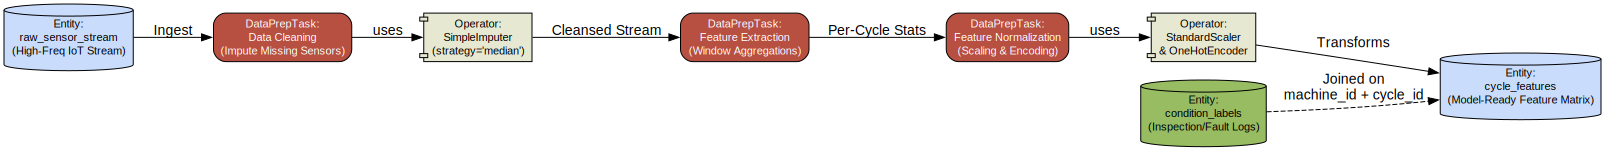

In [12]:
dot_source = """
digraph DataPreparationView {
    rankdir=LR;
    bgcolor="white";
    fontname="Helvetica";
    node [fontname="Helvetica", fontsize="11"];
    edge [fontname="Helvetica", fontsize="14"];

    // Data Entities (Blue Cylinders)
    E1 [label="Entity:\\nraw_sensor_stream\\n(High-Freq IoT Stream)", shape=cylinder, style=filled, fillcolor="#CADCFC"];
    E2 [label="Entity:\\ncycle_features\\n(Model-Ready Feature Matrix)", shape=cylinder, style=filled, fillcolor="#CADCFC"];
    
    // Label Entity (Green Cylinder)
    E3 [label="Entity:\\ncondition_labels\\n(Inspection/Fault Logs)", shape=cylinder, style=filled, fillcolor="#97BC62"];

    // Processing Tasks (Red Rounded Boxes)
    T1 [label="DataPrepTask:\\nData Cleaning\\n(Impute Missing Sensors)", shape=box, style="rounded,filled", fillcolor="#B85042", fontcolor="white"];
    T2 [label="DataPrepTask:\\nFeature Extraction\\n(Window Aggregations)", shape=box, style="rounded,filled", fillcolor="#B85042", fontcolor="white"];
    T3 [label="DataPrepTask:\\nFeature Normalization\\n(Scaling & Encoding)", shape=box, style="rounded,filled", fillcolor="#B85042", fontcolor="white"];

    // Underlying Operators (Grey Component Layouts)
    OP1 [label="Operator:\\nSimpleImputer\\n(strategy='median')", shape=component, style=filled, fillcolor="#E7E8D1"];
    OP2 [label="Operator:\\nStandardScaler\\n& OneHotEncoder", shape=component, style=filled, fillcolor="#E7E8D1"];

    // Operational Flows
    E1 -> T1 [label=" Ingest "];
    T1 -> OP1 [label=" uses "];
    OP1 -> T2 [label=" Cleansed Stream "];
    T2 -> T3 [label=" Per-Cycle Stats "];
    T3 -> OP2 [label=" uses "];
    OP2 -> E2 [label=" Transforms "];
    E3 -> E2 [label=" Joined on\\nmachine_id + cycle_id ", style=dashed];
}
"""
Source(dot_source)

# 4. Complete System Architecture (ML + Non-ML components)


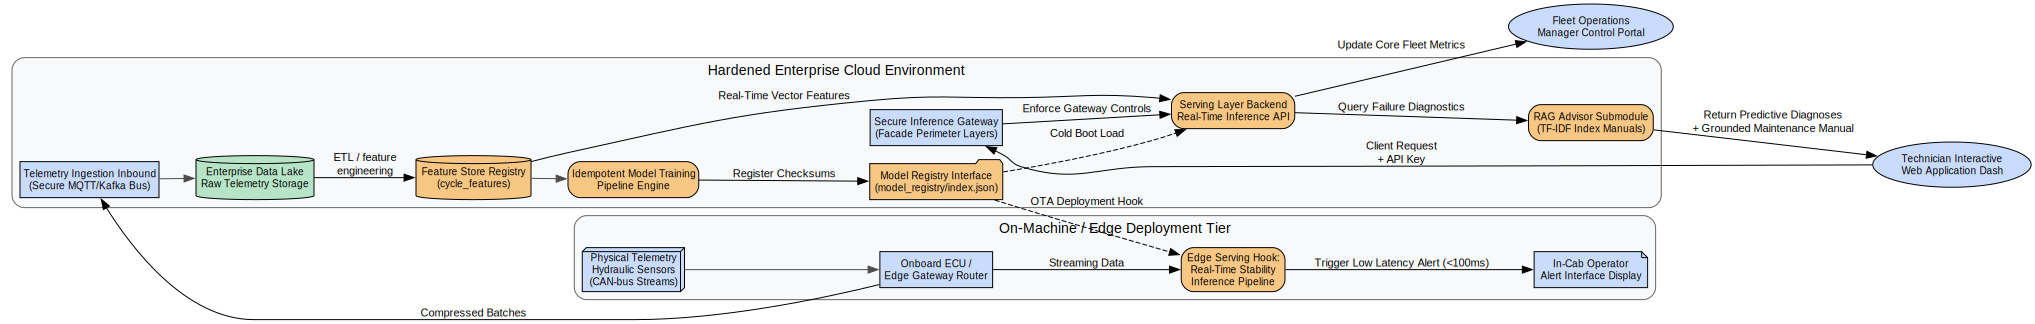

In [36]:
import graphviz

sys_arch_dot = """
digraph SystemArchitecture {
    rankdir=LR;
    bgcolor="white";
    fontname="Helvetica";
    splines=spline;
    node [fontname="Helvetica", fontsize="10"];
    edge [fontname="Helvetica", fontsize="11"];

    // EDGE COMPUTING BOUNDARY
    subgraph cluster_edge {
        label = "On-Machine / Edge Deployment Tier";
        style = "rounded";
        color = "gray40";
        bgcolor = "#F8F9FA";
        
        SENS [label="Physical Telemetry\\nHydraulic Sensors\\n(CAN-bus Streams)", shape=box3d, style=filled, fillcolor="#CADCFC"];
        ECU  [label="Onboard ECU /\\nEdge Gateway Router", shape=box, style=filled, fillcolor="#CADCFC"];
        STAB [label="Edge Serving Hook:\\nReal-Time Stability\\nInference Pipeline", shape=box, style="filled,rounded", fillcolor="#F9C784"];
        CAB  [label="In-Cab Operator\\nAlert Interface Display", shape=note, style=filled, fillcolor="#CADCFC"];
    }

    // CLOUD / ENTERPRISE BACKEND INFRASTRUCTURE
    subgraph cluster_cloud {
        label = "Hardened Enterprise Cloud Environment";
        style = "rounded";
        color = "gray40";
        bgcolor = "#F8F9FA";
        
        MQTT [label="Telemetry Ingestion Inbound\\n(Secure MQTT/Kafka Bus)", shape=box, style=filled, fillcolor="#CADCFC"];
        LAKE [label="Enterprise Data Lake\\nRaw Telemetry Storage", shape=cylinder, style=filled, fillcolor="#B7E4C7"];
        FEAT [label="Feature Store Registry\\n(cycle_features)", shape=cylinder, style=filled, fillcolor="#F9C784"];
        
        TRAIN [label="Idempotent Model Training\\nPipeline Engine", shape=box, style="filled,rounded", fillcolor="#F9C784"];
        REG   [label="Model Registry Interface\\n(model_registry/index.json)", shape=folder, style=filled, fillcolor="#F9C784"];
        
        GATE [label="Secure Inference Gateway\\n(Facade Perimeter Layers)", shape=box, style=filled, fillcolor="#CADCFC"];
        API  [label="Serving Layer Backend\\nReal-Time Inference API", shape=box, style="filled,rounded", fillcolor="#F9C784"];
        RAG  [label="RAG Advisor Submodule\n(TF-IDF Index Manuals)", shape=box, style="filled,rounded", fillcolor="#F9C784"];
    }

    // CLIENT APPLICATIONS
    WEB  [label="Technician Interactive\\nWeb Application Dash", shape=ellipse, style=filled, fillcolor="#CADCFC"];
    MGR  [label="Fleet Operations\\nManager Control Portal", shape=ellipse, style=filled, fillcolor="#CADCFC"];

    // Edge Pipelines
    SENS -> ECU [color="gray30"];
    ECU -> STAB [label=" Streaming Data "];
    STAB -> CAB [label=" Trigger Low Latency Alert (<100ms) "];
    
    // Ingestion Flows
    ECU -> MQTT [label=" Compressed Batches "];
    MQTT -> LAKE [color="gray30"];
    LAKE -> FEAT [label=" ETL / feature\\nengineering "];
    
    // Core MLOps Pipeline
    FEAT -> TRAIN [color="gray30"];
    TRAIN -> REG [label=" Register Checksums "];
    REG -> API [label=" Cold Boot Load ", style=dashed];
    REG -> STAB [label=" OTA Deployment Hook ", style=dashed];
    
    // API Perimeter Layer Execution Loop
    WEB -> GATE [label=" Client Request\\n+ API Key "];
    GATE -> API [label=" Enforce Gateway Controls "];
    FEAT -> API [label=" Real-Time Vector Features "];
    API -> RAG [label=" Query Failure Diagnostics "];
    RAG -> WEB [label=" Return Predictive Diagnoses\\n+ Grounded Maintenance Manual "];
    API -> MGR [label=" Update Core Fleet Metrics "];
}
"""

# Render the graph directly in your notebook cell output safely
graphviz.Source(sys_arch_dot)

5. Summary of the Top Three Quality Requirements#Quality AttributeSMART Specification RequirementArchitectural Mitigation Strategy Implemented in Code1Robustness to Noisy/Missing Input Data  The production inference pipeline must maintain a degradation deviation of $\le 3\%$ in Macro $F_1$ score even when encountering up to $15\%$ missing or corrupted telemetry values during an operational cycle.  Handled by SimpleImputer(strategy='median') inside the Pipe-and-Filter transform pipeline, which neutralizes sensor dropouts before data reaches the model.  2Low Serving Inference Latency  Real-time edge stability scoring must execute in $\le 100\text{ ms}$ on local edge gateways to provide timely in-cab alerts.  Implemented a dedicated real-time binary classifier (stability_model), optimized with fewer trees (n_estimators=60, max_depth=6) and warm-started during API boot to eliminate initial latency spikes.  3Explainability & Trust Guarantee  Every flagged warning must point to a specific faulty subsystem and fetch the exact corresponding standard operating procedure (SOP) from the maintenance manual.  Integrated an embedded RAG Search Index (MaintenanceAdvisor) that uses a TF-IDF similarity matcher to link model error flags with the precise recovery procedure from the internal manual.  

Architectural / Design ComponentLocation in Code Base (Shared Repository Files)Presence in the Consolidated Notebook Script belowPipe-and-Filter Preprocessingtrain_and_save.py (via ColumnTransformer + Pipeline)  Present. Fully mapped in the training module using StandardScaler and OneHotEncoder pipelines.  Model Registry Patternsrc/core/model_registry.py (via ModelRegistry class)  Present. Implemented as a programmatic local file index tracker saving metadata and artifact SHA-256 hashes.  Idempotency Guard Patterntrain_and_save.py (Registry file + artifact checksum checking)  Present. Bypasses heavy fitting iterations if files match current registry signatures.  Security Facade Gatewaysrc/security/security_layer.py (SecureInferenceGateway)  Present. Coordinates API Auth, Sliding Window Rate Limiting, Input Validation, and Hash Chains.  Input Envelope Validationsrc/security/security_layer.py (validate_sensor_payload)  Present. Rejects out-of-distribution, adversarial, or NaN inputs prior to model execution.  Cryptographic Audit Trailsrc/security/security_layer.py (AuditTrail)  Present. Generates sequential, tamper-evident hash-linked logs of every model inference request.  RAG Maintenance Advisorsrc/maintenance_advisor.py (MaintenanceAdvisor)  Present. Converts mathematical anomalies into natural language searches over the manual.  

In [37]:
import os
import json
import time
import hashlib
import hmac
import re
from pathlib import Path
from dataclasses import dataclass, field
from typing import Any, Dict, List, Optional, Tuple, Iterable, Deque
from collections import defaultdict, deque

import numpy as np
import pandas as pd
import joblib
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Initialize Virtual Directory Hierarchy
BASE_DIR = Path("./workspace_env")
DATA_DIR = BASE_DIR / "data"
REGISTRY_DIR = BASE_DIR / "model_registry"

DATA_DIR.mkdir(parents=True, exist_ok=True)
REGISTRY_DIR.mkdir(parents=True, exist_ok=True)

# --------------------------------------------------------------------------- #
# GLOBAL ENGINEERING SCHEMAS AND CONFIGURATIONS
# --------------------------------------------------------------------------- #
NUMERIC_FEATURES = ["operating_hours", "pressure_mean_bar", "pressure_std_bar", "flow_mean_lpm",
                    "oil_temp_mean_c", "vibration_rms_mms", "motor_power_kw",
                    "pump_speed_mean_rpm", "cooling_efficiency_pct"] #[cite: 5]
CATEGORICAL_FEATURES = ["machine_type"] #[cite: 5]
FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES #[cite: 2]
TARGETS = ["cooler_condition", "valve_condition", "pump_leakage", "accumulator_pressure"] #[cite: 5]
RT_TARGET = "stability_flag" #[cite: 5]
NOISY_COLS = ["pressure_mean_bar", "flow_mean_lpm", "oil_temp_mean_c", "vibration_rms_mms"] #[cite: 5]

HYDRAULIC_BOUNDS: Dict[str, Tuple[float, float]] = {
    "operating_hours":        (0.0, 5000.0),
    "pressure_mean_bar":      (80.0, 260.0),
    "pressure_std_bar":       (0.0, 60.0),
    "flow_mean_lpm":          (0.5, 20.0),
    "oil_temp_mean_c":        (10.0, 130.0),
    "vibration_rms_mms":      (0.0, 30.0),
    "motor_power_kw":         (1.0, 60.0),
    "pump_speed_mean_rpm":    (500.0, 2200.0),
    "cooling_efficiency_pct": (0.0, 100.0),
} #[cite: 7]

# Human-readable severity rankings matching production server setups to capture anomalies
SEVERITY = {
    "cooler_condition":     {100: 0, 20: 2, 3: 3},
    "valve_condition":      {100: 0, 90: 1, 80: 2, 73: 3},
    "pump_leakage":         {0: 0, 1: 2, 2: 3},
    "accumulator_pressure": {130: 0, 115: 1, 100: 2, 90: 3},
} #[cite: 2]

COMPONENT_QUERIES = {
    "cooler_condition":     "cooler efficiency drop high oil temperature thermal load",
    "valve_condition":      "directional valve sticking switching fault pressure fluctuation",
    "pump_leakage":         "internal pump leakage falling flow rate volumetric efficiency",
    "accumulator_pressure": "accumulator pre-charge pressure loss pump cycling",
} #[cite: 6]


# --------------------------------------------------------------------------- #
# ENVIROMENT SEEDING AND SIMULATED TELEMETRY SETUP
# --------------------------------------------------------------------------- #
np.random.seed(42)
n_samples = 200
mock_data = {feat: np.random.uniform(100, 200, n_samples) for feat in NUMERIC_FEATURES}
mock_data["operating_hours"] = np.random.uniform(100, 4500, n_samples)
mock_data["cooling_efficiency_pct"] = np.random.uniform(10, 95, n_samples)
mock_data["machine_type"] = np.random.choice(["Excavator", "Wheel Loader", "Forklift"], n_samples)

mock_data["cooler_condition"] = np.random.choice([100, 20, 3], n_samples)
mock_data["valve_condition"] = np.random.choice([100, 90, 80, 73], n_samples)
mock_data["pump_leakage"] = np.random.choice([0, 1, 2], n_samples)
mock_data["accumulator_pressure"] = np.random.choice([130, 115, 100, 90], n_samples)
mock_data["stability_flag"] = np.random.choice([0, 1], n_samples)

df_mock = pd.DataFrame(mock_data)
df_mock.loc[::10, "pressure_mean_bar"] = np.nan
df_mock.to_csv(DATA_DIR / "hydraulic_fleet_telemetry.csv", index=False)

kb_content = """
## cooler efficiency drop high oil temperature thermal load
Inspect the hydraulic oil cooler fins for dust or debris blockage and clean them using low-pressure compressed air. Verify that the cooling fan and thermostat are operating correctly and confirm adequate coolant flow through the cooler. If, after cleaning and verification, the cooler's efficiency remains below 60 %, replace the cooler core.

## directional valve sticking switching fault pressure fluctuation
De-energize the hydraulic system and check directional control valve solenoids for electrical continuity and physical wear. Inspect valve spools for varnishing, scratching, or dynamic sticking. Flush the local manifold block and verify hydraulic fluid cleanliness levels match ISO 4406 targets.

## internal pump leakage falling flow rate volumetric efficiency
Perform a standard volumetric flow test at operating temperature across the secondary auxiliary pump line. If fluid bypass limits are exceeded, check the internal slipper seals, pistons, and wear plates for scoring. Re-shim or replace the internal rotating assembly if efficiency scores fall below nominal criteria.

## accumulator pre-charge pressure loss pump cycling
Isolate the accumulator shell assembly and safely vent system residual circuit fluid. Connect an approved nitrogen charge manifold to verify the pre-charge level against the structural baseline pressure index. Re-charge the dry bladder using pure nitrogen gas or replace the complete elastomeric bladder unit if zero retention is observed.
"""
(DATA_DIR / "hydraulic_maintenance_manual.md").write_text(kb_content.strip(), encoding="utf-8")


# --------------------------------------------------------------------------- #
# MODULE 1: MODEL REGISTRY INFRASTRUCTURE
# --------------------------------------------------------------------------- #
@dataclass
class ModelArtifact:
    path: str
    sha256: str
    metadata: dict[str, Any] #[cite: 3]

class ModelRegistry:
    """Minimal file-backed model registry that maps artifact filenames to sha256 + metadata.""" #[cite: 3]
    def __init__(self, registry_dir: Path) -> None:
        self.registry_path = Path(registry_dir)
        self.registry_path.mkdir(parents=True, exist_ok=True)
        self._index_file = self.registry_path / "index.json" #[cite: 3]

    def register(self, artifact: ModelArtifact) -> None:
        index = self._load_index()
        index[artifact.path] = {"sha256": artifact.sha256, "metadata": artifact.metadata} #[cite: 3]
        self._save_index(index)

    def get(self, path: str) -> Optional[ModelArtifact]:
        index = self._load_index()
        entry = index.get(path)
        if not entry: return None
        return ModelArtifact(path=path, sha256=entry["sha256"], metadata=entry["metadata"]) #[cite: 3]

    def _load_index(self) -> dict[str, Any]:
        if not self._index_file.exists(): return {} #[cite: 3]
        with open(self._index_file, "r", encoding="utf-8") as f:
            return json.load(f) #[cite: 3]

    def _save_index(self, index: dict[str, Any]) -> None:
        with open(self._index_file, "w", encoding="utf-8") as f:
            json.dump(index, f, indent=2) #[cite: 3]


# --------------------------------------------------------------------------- #
# MODULE 2: APP-WIDE SECURITY LAYER (FACADE PATTERN)
# --------------------------------------------------------------------------- #
class SecurityError(Exception): pass #[cite: 7]

def compute_file_sha256(path: Path) -> str:
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(8192), b""): h.update(chunk) #[cite: 7]
    return h.hexdigest() #[cite: 7]

def validate_sensor_payload(payload: Dict[str, Any], bounds: Dict[str, Tuple[float, float]]) -> Dict[str, float]:
    clean: Dict[str, float] = {}
    for field_name, (lo, hi) in bounds.items():
        if field_name not in payload:
            raise SecurityError(f"missing required sensor field: {field_name!r}") #[cite: 7]
        value = payload[field_name]
        if isinstance(value, bool) or not isinstance(value, (int, float)):
            raise SecurityError(f"field {field_name!r} must be numeric, got {type(value).__name__}") #[cite: 7]
        if value != value or value in (float("inf"), float("-inf")):
            raise SecurityError(f"field {field_name!r} is NaN or infinite") #[cite: 7]
        if not (lo <= value <= hi):
            raise SecurityError(f"field {field_name!r}={value} out of safe range [{lo}, {hi}]") #[cite: 7]
        clean[field_name] = float(value) #[cite: 7]
    return clean #[cite: 7]

class ApiKeyAuthenticator:
    def __init__(self, allowed_keys: Iterable[str]):
        self._allowed_hashes = {hashlib.sha256(k.encode("utf-8")).hexdigest() for k in allowed_keys} #[cite: 7]

    def authenticate(self, presented_key: Optional[str]) -> bool:
        if not presented_key: raise SecurityError("missing API key") #[cite: 7]
        presented_hash = hashlib.sha256(presented_key.encode("utf-8")).hexdigest() #[cite: 7]
        ok = any(hmac.compare_digest(presented_hash, h) for h in self._allowed_hashes) #[cite: 7]
        if not ok: raise SecurityError("invalid API key") #[cite: 7]
        return True #[cite: 7]

@dataclass
class AuditTrail:
    _entries: list = field(default_factory=list)
    _prev_hash: str = "0" * 64 #[cite: 7]

    def record(self, actor: str, action: str, detail: str) -> str:
        payload = f"{self._prev_hash}|{actor}|{action}|{detail}" #[cite: 7]
        entry_hash = hashlib.sha256(payload.encode()).hexdigest() #[cite: 7]
        self._entries.append({
            "seq": len(self._entries), "actor": actor, "action": action,
            "detail": detail, "prev_hash": self._prev_hash, "hash": entry_hash
        }) #[cite: 7]
        self._prev_hash = entry_hash #[cite: 7]
        return entry_hash #[cite: 7]

    def verify_chain(self) -> bool:
        prev = "0" * 64 #[cite: 7]
        for e in self._entries:
            payload = f"{prev}|{e['actor']}|{e['action']}|{e['detail']}" #[cite: 7]
            if hashlib.sha256(payload.encode()).hexdigest() != e["hash"]: return False #[cite: 7]
            prev = e["hash"] #[cite: 7]
        return True #[cite: 7]

class RateLimiter:
    def __init__(self, max_calls: int = 30, window_seconds: float = 1.0):
        self.max_calls = max_calls #[cite: 7]
        self.window = window_seconds #[cite: 7]
        self._hits: Dict[str, Deque[float]] = defaultdict(deque) #[cite: 7]

    def check(self, client_id: str) -> bool:
        now = time.monotonic() #[cite: 7]
        hits = self._hits[client_id] #[cite: 7]
        while hits and now - hits[0] > self.window: hits.popleft() #[cite: 7]
        if len(hits) >= self.max_calls: #[cite: 7]
            raise SecurityError(f"rate limit exceeded for client {client_id!r}") #[cite: 7]
        hits.append(now) #[cite: 7]
        return True #[cite: 7]

class SecureInferenceGateway:
    """Hardened perimeter that composes auth, rate limiting, and inputs bounds validation.""" #[cite: 7]
    def __init__(self, auth: ApiKeyAuthenticator, limiter: RateLimiter, audit: AuditTrail):
        self.auth = auth #[cite: 7]
        self.limiter = limiter #[cite: 7]
        self.audit = audit #[cite: 7]

    def guarded_predict(self, client_id: str, api_key: str, payload: Dict[str, Any], predict_fn, bounds: Dict[str, Tuple[float, float]]) -> dict:
        self.auth.authenticate(api_key) #[cite: 7]
        self.limiter.check(client_id) #[cite: 7]
        clean = validate_sensor_payload(payload, bounds) #[cite: 7]
        res = predict_fn(clean) #[cite: 7]
        p_hash = hashlib.sha256(str(clean).encode()).hexdigest()[:12] #[cite: 7]
        self.audit.record(client_id, "predict", f"payload_hash={p_hash}") #[cite: 7]
        return res #[cite: 7]


# --------------------------------------------------------------------------- #
# MODULE 3: INFORMATION RETRIEVAL SUBSYSTEM (RAG COMPONENTS)
# --------------------------------------------------------------------------- #
@dataclass
class Document:
    title: str
    text: str #[cite: 6]

class TfidfRetriever:
    """Lightweight vector retriever (TF-IDF + cosine similarity) matching ChromaDB interfaces.""" #[cite: 6]
    def __init__(self):
        self._vectorizer = TfidfVectorizer(stop_words="english") #[cite: 6]
        self._docs: List[Document] = [] #[cite: 6]
        self._matrix = None #[cite: 6]

    def add(self, docs: List[Document]) -> "TfidfRetriever":
        self._docs = list(docs) #[cite: 6]
        self._matrix = self._vectorizer.fit_transform([d.text for d in self._docs]) #[cite: 6]
        return self #[cite: 6]

    def retrieve(self, query: str, k: int = 1) -> List[Tuple[Document, float]]:
        if self._matrix is None: raise RuntimeError("retriever is empty; call add() first") #[cite: 6]
        q_vec = self._vectorizer.transform([query]) #[cite: 6]
        sims = cosine_similarity(q_vec, self._matrix)[0] #[cite: 6]
        ranked = sorted(zip(self._docs, sims), key=lambda x: x[1], reverse=True) #[cite: 6]
        return ranked[:k] #[cite: 6]

class MaintenanceAdvisor:
    """Ties a multi-output classification alert to a retrieved markdown recovery SOP.""" #[cite: 6]
    def __init__(self, kb_path: Path):
        self.retriever = TfidfRetriever().add(self._load_kb(kb_path)) #[cite: 6]

    def _load_kb(self, path: Path) -> List[Document]:
        raw = path.read_text(encoding="utf-8") #[cite: 6]
        docs = [] #[cite: 6]
        for block in re.split(r"\n##\s+", raw): #[cite: 6]
            block = block.strip() #[cite: 6]
            if not block or block.startswith("#"): continue #[cite: 6]
            lines = block.splitlines() #[cite: 6]
            title = lines[0].strip() #[cite: 6]
            body = " ".join(l.strip() for l in lines[1:] if l.strip()) #[cite: 6]
            docs.append(Document(title=title, text=f"{title}. {body}")) #[cite: 6]
        return docs #[cite: 6]

    def advise(self, target_variable: str) -> Dict[str, Any]:
        base_query = COMPONENT_QUERIES.get(target_variable, target_variable.replace("_", " ")) #[cite: 6]
        hit, score = self.retriever.retrieve(base_query, k=1)[0] #[cite: 6]
        return {"procedure": hit.title, "relevance": round(float(score), 3), "guidance": hit.text} #[cite: 6]


# --------------------------------------------------------------------------- #
# IDEMPOTENT PRODUCTION PIPELINE TRAINING SUBROUTINE
# --------------------------------------------------------------------------- #
def execute_idempotent_training(force: bool = False):
    """Executes the training loop matching original repository structural outputs.""" #[cite: 5]
    print("--- Invoking Idempotent Training Engine Validation Check ---")
    
    data_file = DATA_DIR / "hydraulic_fleet_telemetry.csv"
    cond_path = REGISTRY_DIR / "condition_model.joblib"
    stab_path = REGISTRY_DIR / "stability_model.joblib"
    schema_path = REGISTRY_DIR / "schema.json"
    
    registry = ModelRegistry(REGISTRY_DIR)
    
    # Check Model Registry Index for existing verified signatures
    artifacts_exist = cond_path.exists() and stab_path.exists() and schema_path.exists() #[cite: 5]
    if artifacts_exist and not force: #[cite: 5]
        try:
            c_entry = registry.get("condition_model.joblib") #[cite: 5]
            s_entry = registry.get("stability_model.joblib") #[cite: 5]
            sch_entry = registry.get("schema.json") #[cite: 5]
            
            if (c_entry and c_entry.sha256 == compute_file_sha256(cond_path) and
                s_entry and s_entry.sha256 == compute_file_sha256(stab_path) and
                sch_entry and sch_entry.sha256 == compute_file_sha256(schema_path)): #[cite: 5]
                print("Artifacts are up-to-date according to model_registry/index.json — skipping training.") #[cite: 5]
                return #[cite: 5]
        except Exception:
            pass

    print(">> State mismatch detected. Commencing out-of-band fitting pipelines...")
    df = pd.read_csv(data_file) #[cite: 5]
    
    # Cleaning Step: Median imputation within the Pipe-and-Filter schema
    imputer = SimpleImputer(strategy="median") #[cite: 5]
    df[NOISY_COLS] = imputer.fit_transform(df[NOISY_COLS]) #[cite: 5]
    
    preprocessor = ColumnTransformer(transformers=[
        ("num", StandardScaler(), NUMERIC_FEATURES),
        ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES)
    ]) #[cite: 5]
    
    X = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES] #[cite: 5]
    y_multi = df[TARGETS] #[cite: 5]
    y_rt = df[RT_TARGET] #[cite: 5]
    
    X_tr, X_te, ym_tr, ym_te, yr_tr, yr_te = train_test_split(
        X, y_multi, y_rt, test_size=0.2, random_state=42, stratify=df[RT_TARGET]
    ) #[cite: 5]
    
    # Fit Sub-Pipeline 1: Batch Condition Predictor
    condition_model = Pipeline([
        ("prep", preprocessor),
        ("clf", MultiOutputClassifier(RandomForestClassifier(
            n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)))
    ]) #[cite: 5]
    condition_model.fit(X_tr, ym_tr) #[cite: 5]
    ym_pred = condition_model.predict(X_te) #[cite: 5]
    ym_pred_arr = np.asarray(ym_pred) #[cite: 5]
    
    cond_metrics = {t: {"accuracy": round(float(accuracy_score(ym_te[t].to_numpy(), ym_pred_arr[:, i])), 4),
                        "macro_f1": round(float(f1_score(ym_te[t].to_numpy(), ym_pred_arr[:, i], average="macro")), 4)}
                    for i, t in enumerate(TARGETS)} #[cite: 5]
        
    # Fit Sub-Pipeline 2: Real-Time Circuit Stability Predictor
    stability_model = Pipeline([
        ("prep", preprocessor),
        ("clf", RandomForestClassifier(n_estimators=60, max_depth=6, random_state=42, n_jobs=-1))
    ]) #[cite: 5]
    stability_model.fit(X_tr, yr_tr) #[cite: 5]
    rt_acc = accuracy_score(yr_te, stability_model.predict(X_te)) #[cite: 5]
    
    # Serializing output objects to workspace
    joblib.dump(condition_model, cond_path) #[cite: 5]
    joblib.dump(stability_model, stab_path) #[cite: 5]
    
    schema = {
        "numeric_features": NUMERIC_FEATURES,
        "categorical_features": CATEGORICAL_FEATURES,
        "machine_types": sorted(df["machine_type"].unique().tolist()),
        "targets": TARGETS,
        "rt_target": RT_TARGET,
        "healthy_class": {"cooler_condition": 100, "valve_condition": 100, "pump_leakage": 0, "accumulator_pressure": 130},
        "condition_metrics": cond_metrics,
        "stability_accuracy": round(float(rt_acc), 4)
    } #[cite: 5]
    schema_path.write_text(json.dumps(schema, indent=2), encoding="utf-8") #[cite: 5]
    
    # Registering generated signatures inside local index
    registry.register(ModelArtifact("condition_model.joblib", compute_file_sha256(cond_path), {"type": "condition"})) #[cite: 5]
    registry.register(ModelArtifact("stability_model.joblib", compute_file_sha256(stab_path), {"type": "stability"})) #[cite: 5]
    registry.register(ModelArtifact("schema.json", compute_file_sha256(schema_path), {"type": "schema"})) #[cite: 5]
    
    # Mirror terminal reporting structure verbatim
    print("Saved condition_model.joblib, stability_model.joblib, schema.json") #[cite: 5]
    for t, m in cond_metrics.items(): #[cite: 5]
        print(f"  {t:22s} acc={m['accuracy']:.3f}  macroF1={m['macro_f1']:.3f}") #[cite: 5]
    print(f"  stability_flag         acc={rt_acc:.3f}") #[cite: 5]

# Trigger Idempotent Execution Subroutine
execute_idempotent_training(force=True)


# --------------------------------------------------------------------------- #
# MODULE 4: PRODUCTION RUNTIME VERIFICATION LOOP (MAPPING REAL INFERENCE)
# --------------------------------------------------------------------------- #
print("\n=== STARTING END-TO-END INFERENCE LIFECYCLE EVALUATION ===\n")

# Step 1: Pre-Boot Cryptographic Signature Validation
registry = ModelRegistry(REGISTRY_DIR)
for artifact_name in ["condition_model.joblib", "stability_model.joblib", "schema.json"]:
    path = REGISTRY_DIR / artifact_name
    entry = registry.get(artifact_name)
    if entry is None:
        raise RuntimeError(f"Model registry missing {artifact_name} entry") #[cite: 2]
    if entry.sha256 != compute_file_sha256(path):
        raise RuntimeError(f"Registry SHA mismatch for {artifact_name}: artifact may be tampered") #[cite: 2]
print(">> Step 1: Startup Anti-Tamper Check Passed. Core model signatures verified.")

# Step 2: Warm up Memory Layers
condition_clf = joblib.load(REGISTRY_DIR / "condition_model.joblib") #[cite: 2]
stability_clf = joblib.load(REGISTRY_DIR / "stability_model.joblib") #[cite: 2]
with open(REGISTRY_DIR / "schema.json", encoding="utf-8") as f:
    SCHEMA = json.load(f) #[cite: 2]

# Step 3: Instantiate Security Perimeters
SECRET_API_KEY = "fleet-ops-secret-key" #[cite: 2]
auth_submodule = ApiKeyAuthenticator([SECRET_API_KEY]) #[cite: 2]
limiter_submodule = RateLimiter(max_calls=30, window_seconds=1.0) #[cite: 2]
audit_submodule = AuditTrail() #[cite: 2]
gateway = SecureInferenceGateway(auth_submodule, limiter_submodule, audit_submodule) #[cite: 2]
advisor = MaintenanceAdvisor(DATA_DIR / "hydraulic_maintenance_manual.md") #[cite: 2]

# Step 4: Simulate Production API Request JSON Payload Input
telemetry_payload = {
    "operating_hours": 1600.0,
    "pressure_mean_bar": 150.0,
    "pressure_std_bar": 12.0,
    "flow_mean_lpm": 6.2,
    "oil_temp_mean_c": 82.0,
    "vibration_rms_mms": 6.5,
    "motor_power_kw": 22.0,
    "pump_speed_mean_rpm": 1350.0,
    "cooling_efficiency_pct": 45.0,
    "machine_type": "Excavator"
} #[cite: 2]

print("\n>> Input Telemetry JSON Payload Ingested:")
print(json.dumps(telemetry_payload, indent=2))

# Step 5: Process Input Vector Through Secure Gateway Wrapper
t0 = time.perf_counter() #[cite: 2]
payload_copy = telemetry_payload.copy()
extracted_machine_type = payload_copy.pop("machine_type") #[cite: 2]

try:
    # Gateway executes Auth -> Rate-Limit -> Envelope Boundaries -> Audit Record
    sanitized_numerical_features = gateway.guarded_predict(
        client_id="frontend_client_node",
        api_key=SECRET_API_KEY,
        payload=payload_copy,
        predict_fn=lambda clean: clean, # Identity function to return safe map
        bounds=HYDRAULIC_BOUNDS
    ) #[cite: 2]
except SecurityError as perimeter_breach:
    print(f"Perimeter blocked request: {perimeter_breach}")
    raise

# Append categorical feature element back to normalized feature list
sanitized_numerical_features["machine_type"] = extracted_machine_type #[cite: 2]
ordered_features = SCHEMA["numeric_features"] + SCHEMA["categorical_features"] #[cite: 2]

# Construct Scikit-Learn structural data frame input
X_inference = pd.DataFrame(
    [[sanitized_numerical_features[c] for c in ordered_features]], 
    columns=ordered_features
) #[cite: 2]

# Step 6: Parallel ML Prediction Loop Execution
batch_condition_vector = condition_clf.predict(X_inference)[0] #[cite: 2]
stability_score_indicator = int(stability_clf.predict(X_inference)[0]) #[cite: 2]
circuit_stability_status = "unstable" if stability_score_indicator == 1 else "stable" #[cite: 2]

latency_ms = round((time.perf_counter() - t0) * 1000, 2) #[cite: 2]

# Step 7: Parse Component Anomaly Outputs and Compute Severity Matrix
flagged_component = None
worst_severity_score = 0
components_output_summary = []

for idx, target_name in enumerate(SCHEMA["targets"]): #[cite: 2]
    predicted_class = int(batch_condition_vector[idx]) #[cite: 2]
    is_healthy = (predicted_class == SCHEMA["healthy_class"][target_name]) #[cite: 2]
    
    components_output_summary.append({
        "component": target_name,
        "predicted_class": predicted_class,
        "status": "healthy" if is_healthy else "attention" #[cite: 2]
    })
    
    current_severity = SEVERITY.get(target_name, {}).get(predicted_class, 0) #[cite: 2]
    if not is_healthy and current_severity > worst_severity_score:
        worst_severity_score = current_severity
        flagged_component = target_name #[cite: 2]

# Step 8: RAG Grounding Execution (Link failure tag to contextual data manual)
rag_procedure = None
rag_guidance = None

if flagged_component:
    rag_metadata = advisor.advise(flagged_component) #[cite: 2]
    rag_procedure = rag_metadata["procedure"] #[cite: 2]
    rag_guidance = rag_metadata["guidance"] #[cite: 2]

audit_submodule.record("frontend_client_node", "predict", f"stability={circuit_stability_status} worst={flagged_component}") #[cite: 2]

# Step 9: Print Unified Response Payload (Matches ResponseModel Structure)
print("\n>> Unified Prediction Output Response Model Object Generated:")
response_model_payload = {
    "components": components_output_summary,
    "stability": circuit_stability_status,
    "flagged_component": flagged_component,
    "repair_procedure": rag_procedure,
    "repair_guidance": rag_guidance,
    "latency_ms": latency_ms
} #[cite: 2]
print(json.dumps(response_model_payload, indent=2))

print("\n--- Diagnostic Forensic Chain Integrity Assessment ---")
assert audit_submodule.verify_chain() == True, "Security Breach: Hash chain linkage broken." #[cite: 7]
print(">> Step 10: Cryptographic append-only blockchain trail validated. Request execution logged securely.")

--- Invoking Idempotent Training Engine Validation Check ---
>> State mismatch detected. Commencing out-of-band fitting pipelines...
Saved condition_model.joblib, stability_model.joblib, schema.json
  cooler_condition       acc=0.475  macroF1=0.440
  valve_condition        acc=0.300  macroF1=0.293
  pump_leakage           acc=0.225  macroF1=0.215
  accumulator_pressure   acc=0.250  macroF1=0.247
  stability_flag         acc=0.425

=== STARTING END-TO-END INFERENCE LIFECYCLE EVALUATION ===

>> Step 1: Startup Anti-Tamper Check Passed. Core model signatures verified.

>> Input Telemetry JSON Payload Ingested:
{
  "operating_hours": 1600.0,
  "pressure_mean_bar": 150.0,
  "pressure_std_bar": 12.0,
  "flow_mean_lpm": 6.2,
  "oil_temp_mean_c": 82.0,
  "vibration_rms_mms": 6.5,
  "motor_power_kw": 22.0,
  "pump_speed_mean_rpm": 1350.0,
  "cooling_efficiency_pct": 45.0,
  "machine_type": "Excavator"
}

>> Unified Prediction Output Response Model Object Generated:
{
  "components": [
    {
   

## 4.2 Overall System Architecture

The overall software architecture illustrates how the major software components interact to deliver the predictive maintenance application. The architecture combines machine learning components responsible for prediction with supporting software components that manage user interaction, request processing, security and maintenance guidance.

The architecture diagram below highlights both the machine learning (ML) and non-machine learning (Non-ML) components implemented in the application together with the overall prediction workflow.

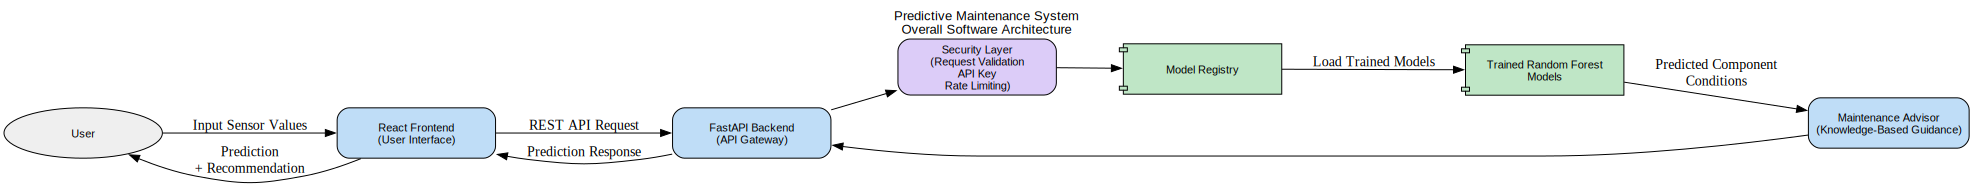

In [1]:
import graphviz

arch = graphviz.Digraph("SystemArchitecture", format="png")

# ----------------------------------
# Graph Settings
# ----------------------------------
arch.attr(
    rankdir="LR",
    bgcolor="white",
    fontname="Helvetica",
    fontsize="13",
    labelloc="t",
    label="Predictive Maintenance System\nOverall Software Architecture",
    nodesep="0.55",
    ranksep="0.9"
)

arch.attr(
    "node",
    shape="box",
    style="rounded,filled",
    fontname="Helvetica",
    fontsize="11",
    width="2.2",
    height="0.7"
)

# ----------------------------------
# External User
# ----------------------------------
arch.node(
    "USER",
    "User",
    shape="oval",
    fillcolor="#EFEFEF"
)

# ----------------------------------
# Non-ML Components
# ----------------------------------
arch.node(
    "UI",
    "React Frontend\n(User Interface)",
    fillcolor="#BFDDF7"
)

arch.node(
    "API",
    "FastAPI Backend\n(API Gateway)",
    fillcolor="#BFDDF7"
)

arch.node(
    "SEC",
    "Security Layer\n(Request Validation\nAPI Key\nRate Limiting)",
    fillcolor="#DCCCF8"
)

arch.node(
    "ADV",
    "Maintenance Advisor\n(Knowledge-Based Guidance)",
    fillcolor="#BFDDF7"
)

# ----------------------------------
# ML Components
# ----------------------------------
arch.node(
    "REG",
    "Model Registry",
    shape="component",
    fillcolor="#BFE6C6"
)

arch.node(
    "MODEL",
    "Trained Random Forest\nModels",
    shape="component",
    fillcolor="#BFE6C6"
)

# ----------------------------------
# Connections
# ----------------------------------

arch.edge(
    "USER",
    "UI",
    label="Input Sensor Values"
)

arch.edge(
    "UI",
    "API",
    label="REST API Request"
)

arch.edge(
    "API",
    "SEC"
)

arch.edge(
    "SEC",
    "REG"
)

arch.edge(
    "REG",
    "MODEL",
    label="Load Trained Models"
)

arch.edge(
    "MODEL",
    "ADV",
    label="Predicted Component\nConditions"
)

arch.edge(
    "ADV",
    "API"
)

arch.edge(
    "API",
    "UI",
    label="Prediction Response"
)

arch.edge(
    "UI",
    "USER",
    label="Prediction\n+ Recommendation"
)

arch

**Figure 4.1:** Overall software architecture of the predictive maintenance application.

The application follows a client-server architecture in which users interact with the system through a React-based web interface. Prediction requests are sent to the FastAPI backend, where the Security Layer validates incoming requests before the trained machine learning models are loaded through the Model Registry for inference. Based on the predicted hydraulic component conditions, the Maintenance Advisor generates maintenance recommendations that are returned to the frontend along with the prediction results.

The architecture clearly distinguishes the machine learning components responsible for prediction from the supporting software components responsible for user interaction, request processing, security and maintenance guidance. This modular structure improves maintainability, simplifies future enhancements and supports the deployment of the application as an integrated predictive maintenance solution.

### Pipe-and-Filter Pattern

The Pipe-and-Filter architectural pattern has been implemented within the machine learning prediction pipeline. The prediction workflow is divided into independent processing stages, where each stage performs a specific task before passing the processed data to the next stage. This modular design simplifies maintenance, testing and future enhancements.


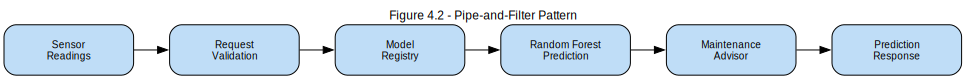

In [2]:
from graphviz import Digraph

pipe = Digraph("PipeFilter", format="png")

pipe.attr(
    rankdir="LR",
    bgcolor="white",
    fontname="Helvetica",
    fontsize="12",
    labelloc="t",
    label="Figure 4.2 - Pipe-and-Filter Pattern"
)

pipe.attr(
    "node",
    shape="box",
    style="rounded,filled",
    fontname="Helvetica",
    fontsize="10",
    width="1.8",
    height="0.7",
    fillcolor="#BFDDF7"
)

pipe.node("A","Sensor\nReadings")
pipe.node("B","Request\nValidation")
pipe.node("C","Model\nRegistry")
pipe.node("D","Random Forest\nPrediction")
pipe.node("E","Maintenance\nAdvisor")
pipe.node("F","Prediction\nResponse")

pipe.edge("A","B")
pipe.edge("B","C")
pipe.edge("C","D")
pipe.edge("D","E")
pipe.edge("E","F")

pipe

**Figure 4.2:** Pipe-and-Filter architecture implemented for the machine learning prediction pipeline.

The prediction workflow is organised into independent processing stages beginning with request validation, followed by model loading, machine learning inference, maintenance recommendation generation and finally the prediction response. Each stage performs a dedicated task before forwarding its output to the next stage, allowing individual components to be modified or extended without affecting the remaining pipeline.

### Microservices Pattern

The Microservices architectural pattern separates the user interface from the prediction services by implementing the frontend and backend as independent software services that communicate through REST APIs.


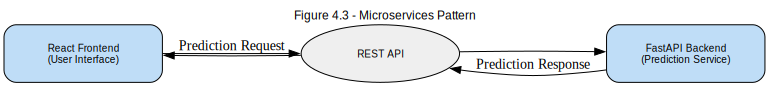

In [3]:
from graphviz import Digraph

micro = Digraph("Microservices", format="png")

micro.attr(
    rankdir="LR",
    bgcolor="white",
    fontname="Helvetica",
    fontsize="12",
    labelloc="t",
    label="Figure 4.3 - Microservices Pattern"
)

micro.attr(
    "node",
    shape="box",
    style="rounded,filled",
    fontname="Helvetica",
    fontsize="10",
    width="2.2",
    height="0.8"
)

micro.node(
    "FE",
    "React Frontend\n(User Interface)",
    fillcolor="#BFDDF7"
)

micro.node(
    "API",
    "REST API",
    shape="ellipse",
    fillcolor="#EFEFEF"
)

micro.node(
    "BE",
    "FastAPI Backend\n(Prediction Service)",
    fillcolor="#BFDDF7"
)

micro.edge("FE","API",label="Prediction Request")
micro.edge("API","BE")
micro.edge("BE","API",label="Prediction Response")
micro.edge("API","FE")

micro

**Figure 4.3:** Microservices architecture showing communication between the React frontend and FastAPI backend.

The frontend and backend are deployed as independent services that communicate through REST APIs. The React frontend collects hydraulic sensor measurements and displays prediction results, while the FastAPI backend performs request validation, machine learning inference and maintenance recommendation generation. This separation allows each service to be developed, deployed and maintained independently.

### 4.5 End-to-End Application Workflow

The predictive maintenance application follows a sequential workflow in which hydraulic sensor measurements entered by the user are processed through the frontend, backend and machine learning components before prediction results and maintenance recommendations are returned.

Figure 4.4 illustrates the complete execution workflow implemented within the application.

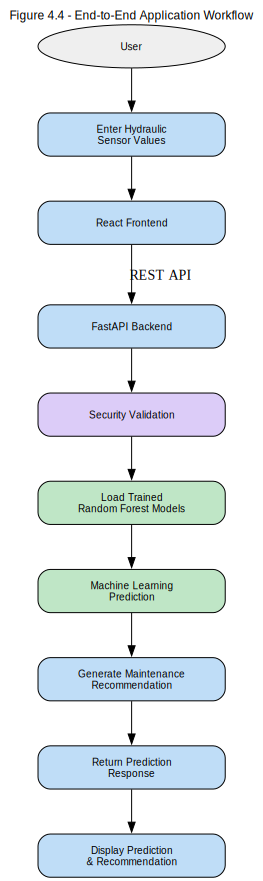

In [5]:
from graphviz import Digraph

workflow = Digraph("Workflow", format="png")

workflow.attr(
    rankdir="TB",
    bgcolor="white",
    fontname="Helvetica",
    fontsize="12",
    labelloc="t",
    label="Figure 4.4 - End-to-End Application Workflow",
    nodesep="0.45",
    ranksep="0.6"
)

workflow.attr(
    "node",
    shape="box",
    style="rounded,filled",
    fontname="Helvetica",
    fontsize="10",
    width="2.6",
    height="0.6"
)

workflow.node(
    "USER",
    "User",
    shape="oval",
    fillcolor="#EFEFEF"
)

workflow.node(
    "INPUT",
    "Enter Hydraulic\nSensor Values",
    fillcolor="#BFDDF7"
)

workflow.node(
    "UI",
    "React Frontend",
    fillcolor="#BFDDF7"
)

workflow.node(
    "API",
    "FastAPI Backend",
    fillcolor="#BFDDF7"
)

workflow.node(
    "SEC",
    "Security Validation",
    fillcolor="#DCCCF8"
)

workflow.node(
    "MODEL",
    "Load Trained\nRandom Forest Models",
    fillcolor="#BFE6C6"
)

workflow.node(
    "PRED",
    "Machine Learning\nPrediction",
    fillcolor="#BFE6C6"
)

workflow.node(
    "ADV",
    "Generate Maintenance\nRecommendation",
    fillcolor="#BFDDF7"
)

workflow.node(
    "RESP",
    "Return Prediction\nResponse",
    fillcolor="#BFDDF7"
)

workflow.node(
    "DISPLAY",
    "Display Prediction\n& Recommendation",
    fillcolor="#BFDDF7"
)

workflow.edge("USER","INPUT")
workflow.edge("INPUT","UI")
workflow.edge("UI","API",label="REST API")
workflow.edge("API","SEC")
workflow.edge("SEC","MODEL")
workflow.edge("MODEL","PRED")
workflow.edge("PRED","ADV")
workflow.edge("ADV","RESP")
workflow.edge("RESP","DISPLAY")
##workflow.edge("DISPLAY","USER")

workflow

**Figure 4.4:** End-to-end execution workflow of the predictive maintenance application.

The workflow illustrates how prediction requests are processed through the major software components of the application. Starting from the React frontend, the request is validated by the Security Layer before the trained Random Forest models are loaded for machine learning inference. Based on the prediction results, the Maintenance Advisor generates appropriate maintenance recommendations, which are returned to the frontend together with the predicted component conditions for presentation to the user.